# 📊 Exploratory Data Analysis — Credit Score Classification

**Problem Statement:** Build a machine learning model to classify customers into credit score brackets (`Good`, `Standard`, `Poor`) based on their financial and behavioral data.

**Dataset Source:** Kaggle — Credit Score Classification  
**Train set:** 100,000 rows × 28 columns  
**Test set:** 50,000 rows × 27 columns  

---
### Table of Contents
1. [Import Libraries & Load Data](#1)
2. [Dataset Overview](#2)
3. [Target Variable Analysis](#3)
4. [Missing Values Analysis](#4)
5. [Data Quality & Anomaly Detection](#5)
6. [Numerical Features Analysis](#6)
7. [Categorical Features Analysis](#7)
8. [Feature Correlations](#8)
9. [Key Findings Summary](#9)

## 1. Import Libraries & Load Data <a id='1'></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

COLORS = {'Good': '#2ecc71', 'Standard': '#3498db', 'Poor': '#e74c3c'}

In [4]:
train = pd.read_csv(r"C:\Users\Admin\[MLOps] train.csv", low_memory=False)
test  = pd.read_csv(r"C:\Users\Admin\[MLOps] test.csv",  low_memory=False)

print(f'Train shape : {train.shape}')
print(f'Test shape  : {test.shape}')
train.head(3)

Train shape : (100000, 28)
Test shape  : (50000, 27)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.84,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,4.00,_,809.98,26.82,22 Years and 1 Months,No,49.57,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.00,Good,809.98,31.94,NaN,No,49.57,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,_,4.00,Good,809.98,28.61,22 Years and 3 Months,No,49.57,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good


## 2. Dataset Overview <a id='2'></a>

In [5]:
# Column types and non-null counts
print('=== TRAIN INFO ===')
train.info()

=== TRAIN INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              

In [6]:
# Statistical summary of numeric columns
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Monthly_Inhand_Salary,84998.00,4194.17,3183.69,303.65,1625.57,3093.75,5957.45,15204.63
Num_Bank_Accounts,100000.00,17.09,117.40,-1.00,3.00,6.00,7.00,1798.00
Num_Credit_Card,100000.00,22.47,129.06,0.00,4.00,5.00,7.00,1499.00
Interest_Rate,100000.00,72.47,466.42,1.00,8.00,13.00,20.00,5797.00
Delay_from_due_date,100000.00,21.07,14.86,-5.00,10.00,18.00,28.00,67.00
Num_Credit_Inquiries,98035.00,27.75,193.18,0.00,3.00,6.00,9.00,2597.00
Credit_Utilization_Ratio,100000.00,32.29,5.12,20.00,28.05,32.31,36.50,50.00
Total_EMI_per_month,100000.00,1403.12,8306.04,0.00,30.31,69.25,161.22,82331.00


In [7]:
# Check column overlap between train and test
train_only = set(train.columns) - set(test.columns)
test_only  = set(test.columns)  - set(train.columns)

print(f'Columns only in TRAIN : {train_only}')   # Should be Credit_Score
print(f'Columns only in TEST  : {test_only}')    # Should be empty
print(f'Shared columns        : {len(set(train.columns) & set(test.columns))}')

Columns only in TRAIN : {'Credit_Score'}
Columns only in TEST  : set()
Shared columns        : 27


## 3. Target Variable Analysis <a id='3'></a>

In [8]:
target_counts = train['Credit_Score'].value_counts()
target_pct    = train['Credit_Score'].value_counts(normalize=True) * 100

print('Credit Score Distribution:')
for label in target_counts.index:
    print(f'  {label:10s}: {target_counts[label]:6,}  ({target_pct[label]:.1f}%)')

Credit Score Distribution:
  Standard  : 53,174  (53.2%)
  Poor      : 28,998  (29.0%)
  Good      : 17,828  (17.8%)


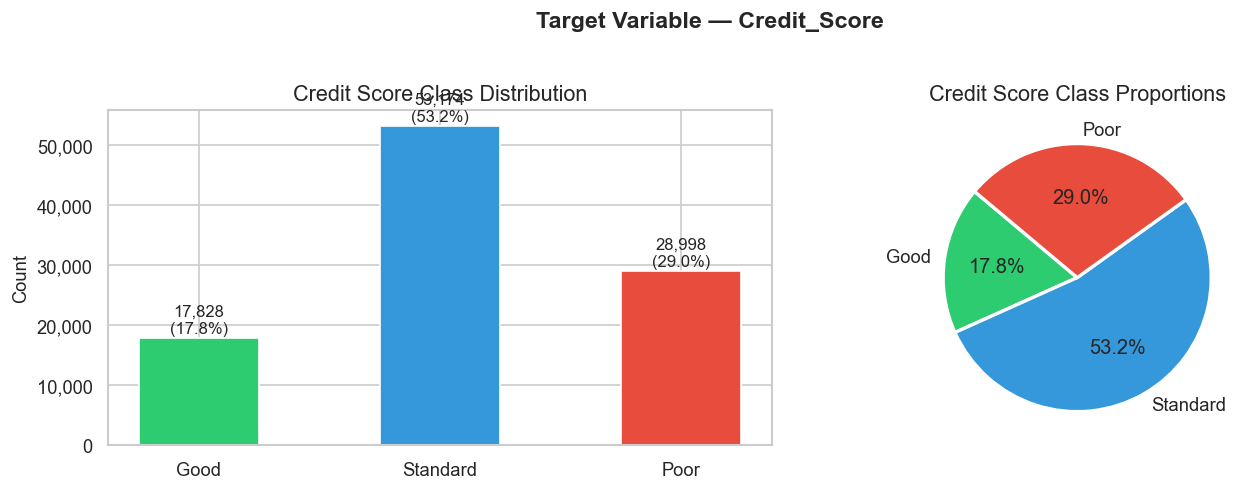


⚠️  Class imbalance detected: Standard dominates at 53.2%, Good is underrepresented at 17.8%.
   → Consider class weighting or resampling strategies during model training.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
order = ['Good', 'Standard', 'Poor']
bars = axes[0].bar(
    order,
    [target_counts[o] for o in order],
    color=[COLORS[o] for o in order],
    edgecolor='white', width=0.5
)
for bar, label in zip(bars, order):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 300,
        f'{target_counts[label]:,}\n({target_pct[label]:.1f}%)',
        ha='center', va='bottom', fontsize=10
    )
axes[0].set_title('Credit Score Class Distribution')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Pie chart
axes[1].pie(
    [target_counts[o] for o in order],
    labels=order,
    colors=[COLORS[o] for o in order],
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Credit Score Class Proportions')

plt.suptitle('Target Variable — Credit_Score', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n⚠️  Class imbalance detected: Standard dominates at 53.2%, Good is underrepresented at 17.8%.')
print('   → Consider class weighting or resampling strategies during model training.')

## 4. Missing Values Analysis <a id='4'></a>

In [10]:
def missing_summary(df, name='DataFrame'):
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    pct = (missing / len(df) * 100).round(2)
    summary = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
    print(f'\n=== {name} — Missing Values ===')
    print(summary.to_string())
    return summary

train_missing = missing_summary(train, 'TRAIN')
test_missing  = missing_summary(test,  'TEST')


=== TRAIN — Missing Values ===
                         Missing Count  Missing %
Monthly_Inhand_Salary            15002      15.00
Type_of_Loan                     11408      11.41
Name                              9985       9.98
Credit_History_Age                9030       9.03
Num_of_Delayed_Payment            7002       7.00
Amount_invested_monthly           4479       4.48
Num_Credit_Inquiries              1965       1.96
Monthly_Balance                   1200       1.20

=== TEST — Missing Values ===
                         Missing Count  Missing %
Monthly_Inhand_Salary             7498      15.00
Type_of_Loan                      5704      11.41
Name                              5015      10.03
Credit_History_Age                4470       8.94
Num_of_Delayed_Payment            3498       7.00
Amount_invested_monthly           2271       4.54
Num_Credit_Inquiries              1035       2.07
Monthly_Balance                    562       1.12


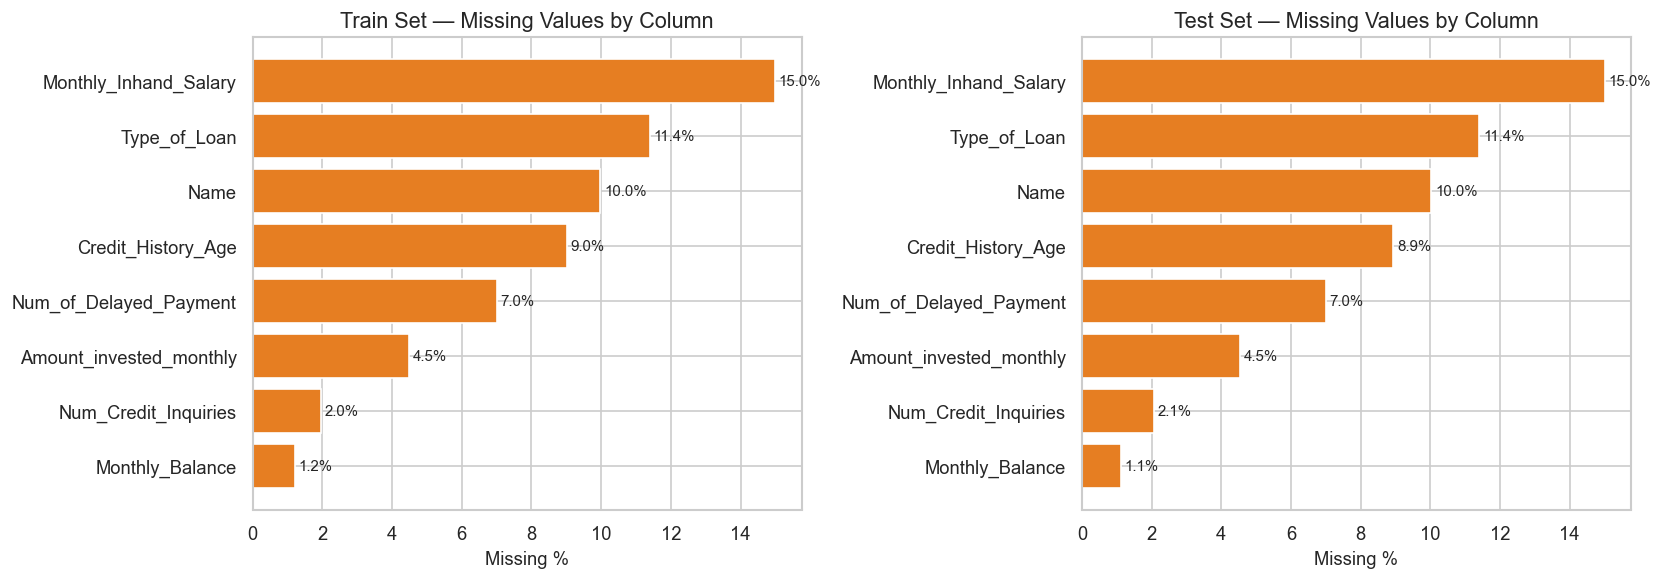

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, summary, title in zip(axes, [train_missing, test_missing], ['Train', 'Test']):
    if summary.empty:
        ax.text(0.5, 0.5, 'No missing values', ha='center', va='center')
    else:
        bars = ax.barh(summary.index, summary['Missing %'], color='#e67e22', edgecolor='white')
        for bar, val in zip(bars, summary['Missing %']):
            ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                    f'{val:.1f}%', va='center', fontsize=9)
        ax.set_xlabel('Missing %')
        ax.set_title(f'{title} Set — Missing Values by Column')
        ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 5. Data Quality & Anomaly Detection <a id='5'></a>

In [12]:
print('=== ANOMALY SUMMARY ===')

# Age: negative values and trailing characters
age_dirty = train['Age'][pd.to_numeric(train['Age'], errors='coerce').isnull() | 
                         (pd.to_numeric(train['Age'], errors='coerce') < 0)]
print(f'\nAge — dirty/negative values   : {len(age_dirty):,}')
print(f'  Negative sample             : {train["Age"][pd.to_numeric(train["Age"], errors="coerce") < 0].unique()[:5].tolist()}')
print(f'  Non-numeric sample          : {train["Age"][pd.to_numeric(train["Age"], errors="coerce").isnull()].unique()[:5].tolist()}')

# SSN: corrupted values
ssn_bad = train['SSN'][~train['SSN'].str.match(r'^\d{3}-\d{2}-\d{4}$', na=False)]
print(f'\nSSN — non-standard format      : {len(ssn_bad):,}')
print(f'  Sample                       : {ssn_bad.unique()[:5].tolist()}')

# Occupation: placeholder
occ_bad = train[train['Occupation'] == '_______']
print(f'\nOccupation — placeholder \'_______\': {len(occ_bad):,}')

# Annual_Income: trailing characters
ai_bad = train['Annual_Income'][pd.to_numeric(train['Annual_Income'], errors='coerce').isnull()]
print(f'\nAnnual_Income — non-numeric    : {len(ai_bad):,}')
print(f'  Sample                       : {ai_bad.unique()[:5].tolist()}')

# Num_Credit_Card: extreme values
ncc_extreme = train[train['Num_Credit_Card'] > 20]
print(f'\nNum_Credit_Card — values > 20  : {len(ncc_extreme):,} (max={train["Num_Credit_Card"].max()})')

# Num_Bank_Accounts: negative and extreme values
nba_bad = train[(train['Num_Bank_Accounts'] < 0) | (train['Num_Bank_Accounts'] > 20)]
print(f'\nNum_Bank_Accounts — out of range: {len(nba_bad):,} (min={train["Num_Bank_Accounts"].min()}, max={train["Num_Bank_Accounts"].max()})')

# Num_of_Loan: extreme values
nol_bad = train[pd.to_numeric(train['Num_of_Loan'], errors='coerce') > 10]
print(f'\nNum_of_Loan — values > 10      : {len(nol_bad):,}')

# Monthly_Balance: garbage placeholder
mb_bad = train['Monthly_Balance'][train['Monthly_Balance'] == '__-333333333333333333333333333__']
print(f'\nMonthly_Balance — garbage placeholder: {len(mb_bad):,}')

# Changed_Credit_Limit: placeholder
ccl_bad = train[train['Changed_Credit_Limit'] == '_']
print(f'\nChanged_Credit_Limit — placeholder \'_\': {len(ccl_bad):,}')

# Credit_Mix: placeholder
cm_bad = train[train['Credit_Mix'] == '_']
print(f'\nCredit_Mix — placeholder \'_\' : {len(cm_bad):,}')

# Payment_Behaviour: garbage
pb_bad = train[train['Payment_Behaviour'] == '!@9#%8']
print(f'\nPayment_Behaviour — garbage \'!@9#%8\': {len(pb_bad):,}')

# Delay_from_due_date: negative
ddd_bad = train[train['Delay_from_due_date'] < 0]
print(f'\nDelay_from_due_date — negative values: {len(ddd_bad):,}')

# Payment_of_Min_Amount: unknown category
pma_nm = train[train['Payment_of_Min_Amount'] == 'NM']
print(f'\nPayment_of_Min_Amount — \'NM\' (unknown): {len(pma_nm):,}')

=== ANOMALY SUMMARY ===

Age — dirty/negative values   : 5,825
  Negative sample             : ['-500']
  Non-numeric sample          : ['28_', '34_', '30_', '24_', '33_']

SSN — non-standard format      : 5,572
  Sample                       : ['#F%$D@*&8']

Occupation — placeholder '_______': 7,062

Annual_Income — non-numeric    : 6,980
  Sample                       : ['34847.84_', '30689.89_', '35547.71_', '34081.38_', '114838.41_']

Num_Credit_Card — values > 20  : 2,263 (max=1499)

Num_Bank_Accounts — out of range: 1,335 (min=-1, max=1798)

Num_of_Loan — values > 10      : 447

Monthly_Balance — garbage placeholder: 9

Changed_Credit_Limit — placeholder '_': 2,091

Credit_Mix — placeholder '_' : 20,195

Payment_Behaviour — garbage '!@9#%8': 7,600

Delay_from_due_date — negative values: 591

Payment_of_Min_Amount — 'NM' (unknown): 12,007


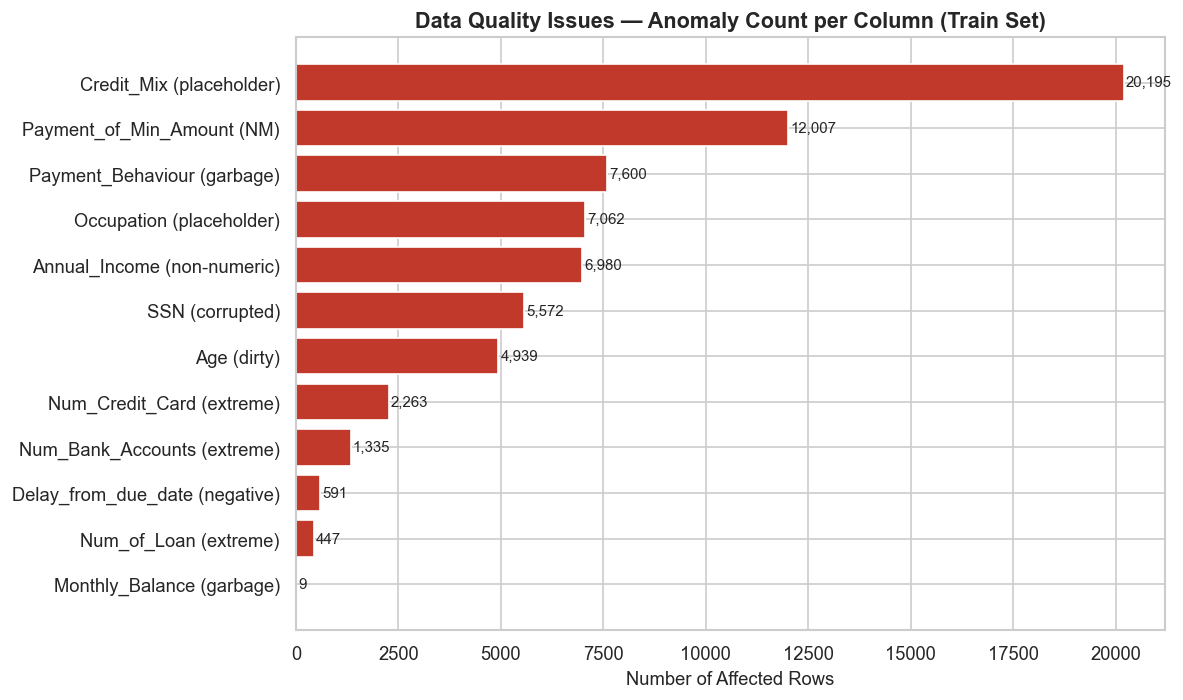

In [13]:
# Visual: anomaly counts by column
anomaly_data = {
    'Age (dirty)':                   len(train['Age'][pd.to_numeric(train['Age'], errors='coerce').isnull()]),
    'SSN (corrupted)':               len(train['SSN'][~train['SSN'].str.match(r'^\d{3}-\d{2}-\d{4}$', na=False)]),
    'Occupation (placeholder)':      len(train[train['Occupation'] == '_______']),
    'Annual_Income (non-numeric)':   len(train['Annual_Income'][pd.to_numeric(train['Annual_Income'], errors='coerce').isnull()]),
    'Num_Credit_Card (extreme)':     len(train[train['Num_Credit_Card'] > 20]),
    'Num_Bank_Accounts (extreme)':   len(train[(train['Num_Bank_Accounts'] < 0) | (train['Num_Bank_Accounts'] > 20)]),
    'Num_of_Loan (extreme)':         len(train[pd.to_numeric(train['Num_of_Loan'], errors='coerce') > 10]),
    'Monthly_Balance (garbage)':     len(train['Monthly_Balance'][train['Monthly_Balance'] == '__-333333333333333333333333333__']),
    'Credit_Mix (placeholder)':      len(train[train['Credit_Mix'] == '_']),
    'Payment_Behaviour (garbage)':   len(train[train['Payment_Behaviour'] == '!@9#%8']),
    'Delay_from_due_date (negative)': len(train[train['Delay_from_due_date'] < 0]),
    'Payment_of_Min_Amount (NM)':    len(train[train['Payment_of_Min_Amount'] == 'NM']),
}

anomaly_series = pd.Series(anomaly_data).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(anomaly_series.index, anomaly_series.values, color='#c0392b', edgecolor='white')
for bar, val in zip(bars, anomaly_series.values):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9)
ax.set_xlabel('Number of Affected Rows')
ax.set_title('Data Quality Issues — Anomaly Count per Column (Train Set)', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Numerical Features Analysis <a id='6'></a>

In [14]:
# Clean numeric versions for EDA purposes only
train_eda = train.copy()
train_eda['Age_clean']            = pd.to_numeric(train_eda['Age'].str.replace(r'[^\d]', '', regex=True), errors='coerce')
train_eda['Age_clean']            = train_eda['Age_clean'].where(train_eda['Age_clean'].between(1, 100))
train_eda['Annual_Income_clean']  = pd.to_numeric(train_eda['Annual_Income'].str.replace('_', '', regex=False), errors='coerce')
train_eda['Num_of_Loan_clean']    = pd.to_numeric(train_eda['Num_of_Loan'].str.replace('_', '', regex=False), errors='coerce')
train_eda['Outstanding_Debt_clean'] = pd.to_numeric(train_eda['Outstanding_Debt'].str.replace('_', '', regex=False), errors='coerce')
train_eda['Monthly_Balance_clean'] = pd.to_numeric(train_eda['Monthly_Balance'].replace('__-333333333333333333333333333__', np.nan), errors='coerce')
train_eda['Num_of_Delayed_Payment_clean'] = pd.to_numeric(train_eda['Num_of_Delayed_Payment'].str.replace('_', '', regex=False), errors='coerce')

# Cap extreme outliers for visualisation
train_eda['Num_Bank_Accounts_capped'] = train_eda['Num_Bank_Accounts'].clip(0, 20)
train_eda['Num_Credit_Card_capped']   = train_eda['Num_Credit_Card'].clip(0, 20)
train_eda['Interest_Rate_capped']     = train_eda['Interest_Rate'].clip(0, 100)

print('Cleaned columns created for EDA.')

Cleaned columns created for EDA.


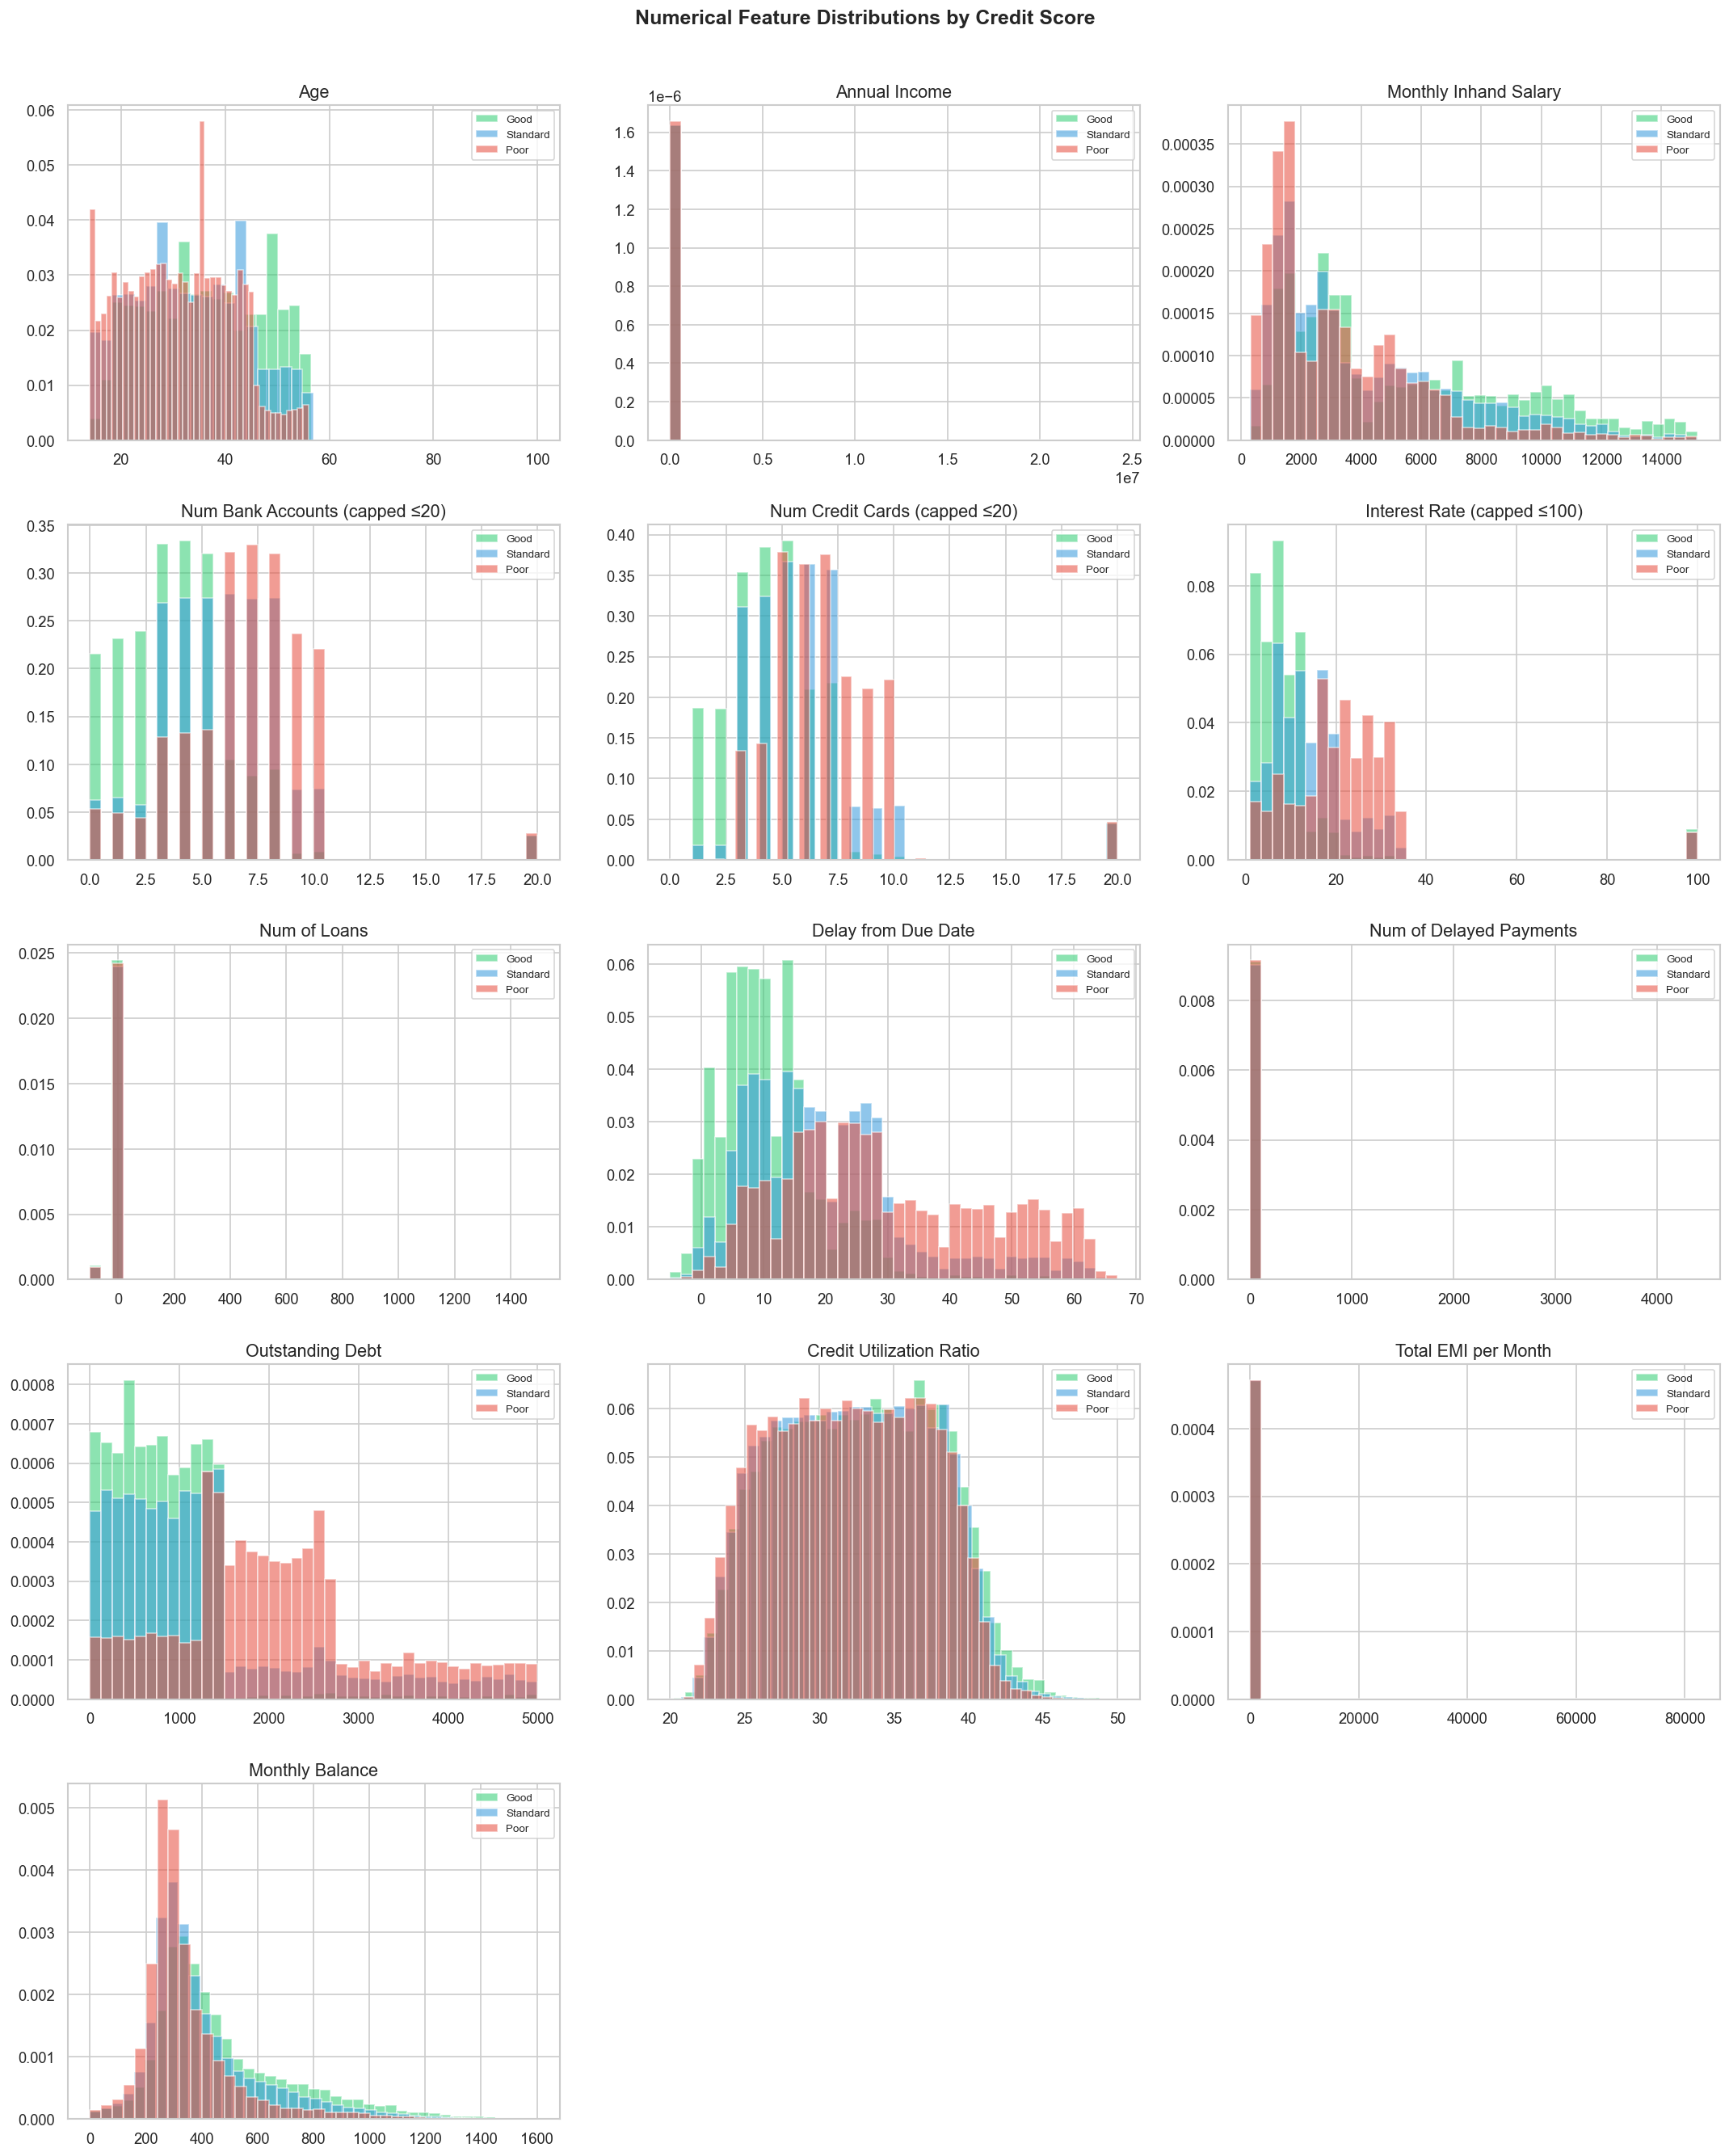

In [15]:
# Distribution of key numeric features by Credit Score
num_features = [
    ('Age_clean',                    'Age'),
    ('Annual_Income_clean',          'Annual Income'),
    ('Monthly_Inhand_Salary',        'Monthly Inhand Salary'),
    ('Num_Bank_Accounts_capped',     'Num Bank Accounts (capped ≤20)'),
    ('Num_Credit_Card_capped',       'Num Credit Cards (capped ≤20)'),
    ('Interest_Rate_capped',         'Interest Rate (capped ≤100)'),
    ('Num_of_Loan_clean',            'Num of Loans'),
    ('Delay_from_due_date',          'Delay from Due Date'),
    ('Num_of_Delayed_Payment_clean', 'Num of Delayed Payments'),
    ('Outstanding_Debt_clean',       'Outstanding Debt'),
    ('Credit_Utilization_Ratio',     'Credit Utilization Ratio'),
    ('Total_EMI_per_month',          'Total EMI per Month'),
    ('Monthly_Balance_clean',        'Monthly Balance'),
]

order = ['Good', 'Standard', 'Poor']
palette = COLORS

fig, axes = plt.subplots(5, 3, figsize=(18, 22))
axes = axes.flatten()

for i, (col, label) in enumerate(num_features):
    for score in order:
        subset = train_eda[train_eda['Credit_Score'] == score][col].dropna()
        axes[i].hist(subset, bins=40, alpha=0.55, label=score, color=palette[score], density=True)
    axes[i].set_title(label)
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)

# Hide unused subplot
for j in range(len(num_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions by Credit Score', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

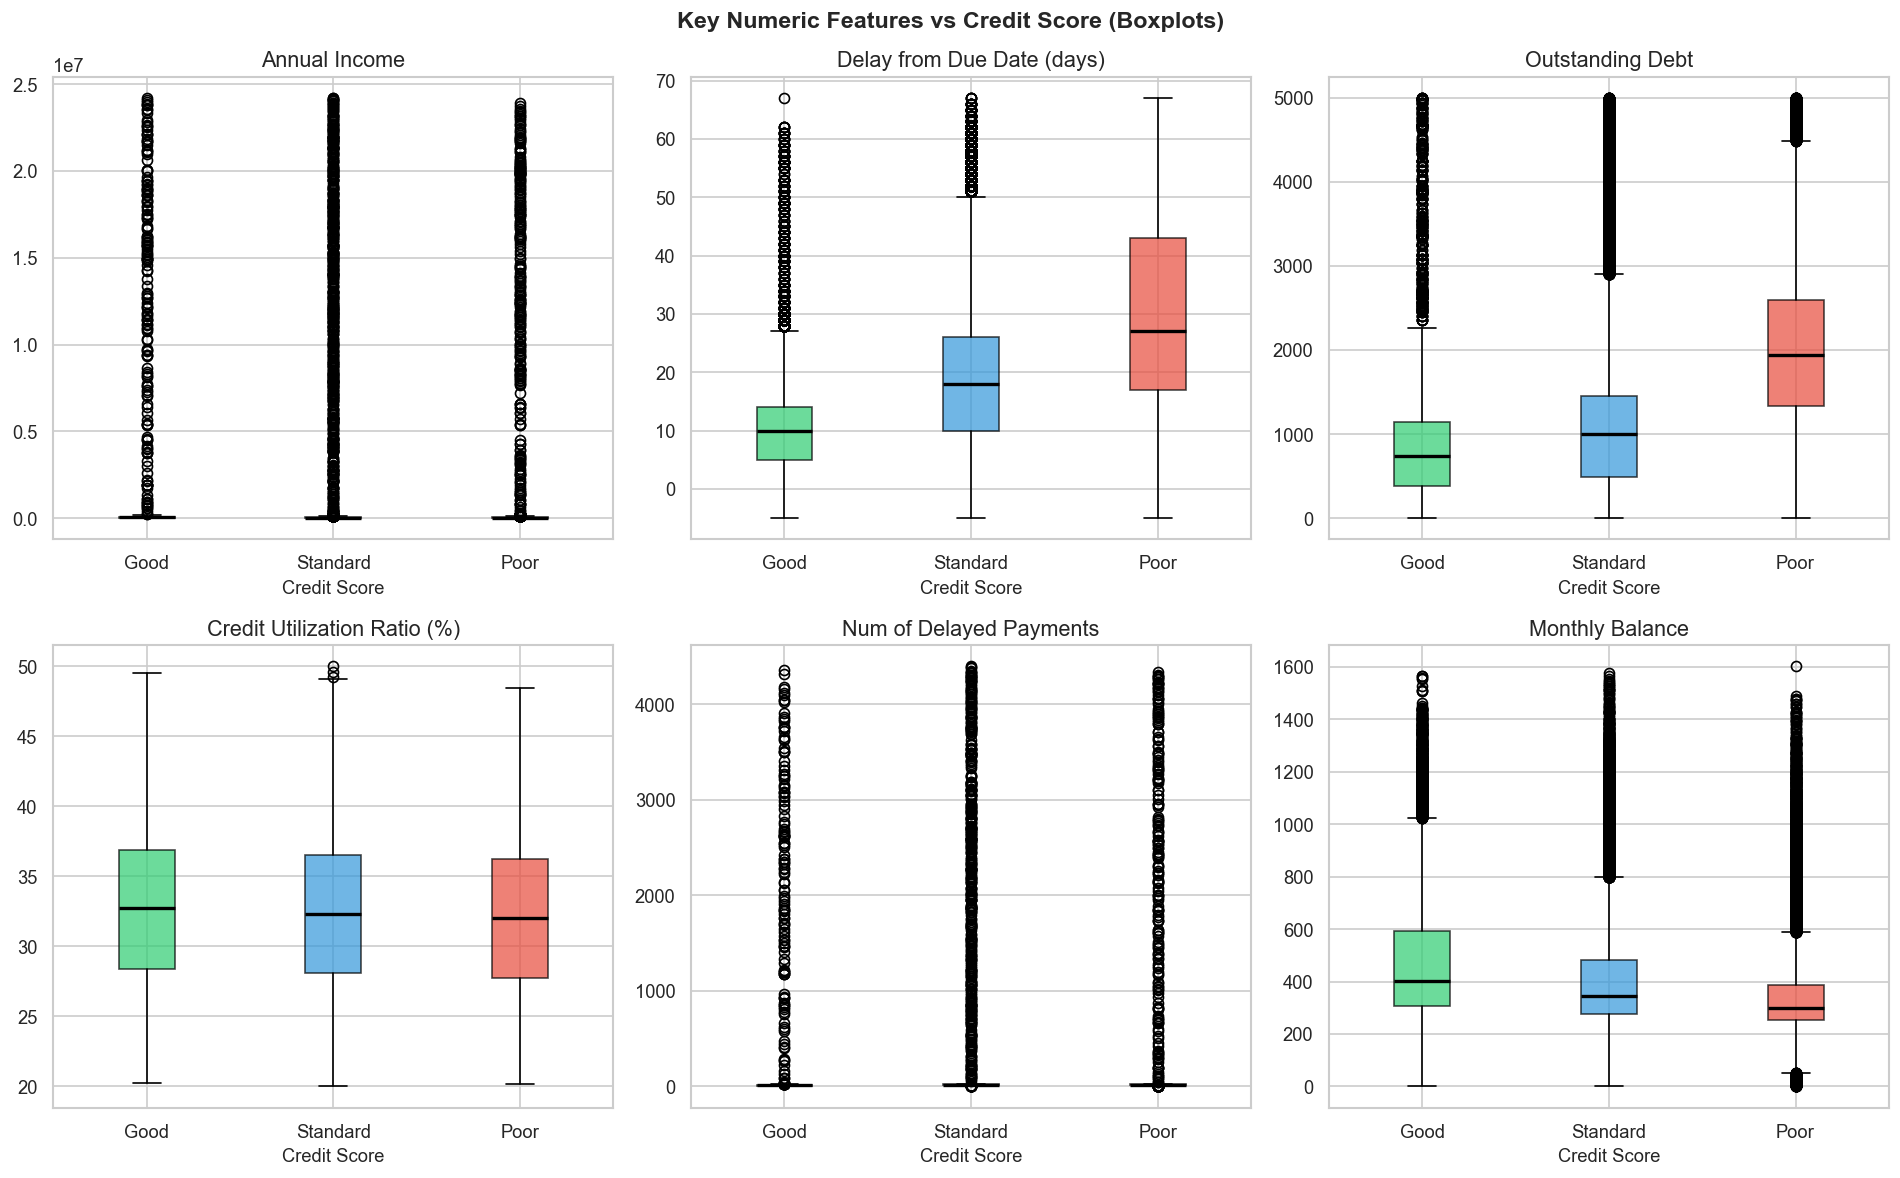

In [16]:
# Boxplots: key numeric features vs Credit Score
box_features = [
    ('Annual_Income_clean',          'Annual Income'),
    ('Delay_from_due_date',          'Delay from Due Date (days)'),
    ('Outstanding_Debt_clean',       'Outstanding Debt'),
    ('Credit_Utilization_Ratio',     'Credit Utilization Ratio (%)'),
    ('Num_of_Delayed_Payment_clean', 'Num of Delayed Payments'),
    ('Monthly_Balance_clean',        'Monthly Balance'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (col, label) in enumerate(box_features):
    data = [train_eda[train_eda['Credit_Score'] == s][col].dropna() for s in order]
    bp = axes[i].boxplot(data, labels=order, patch_artist=True, notch=False,
                         medianprops={'color': 'black', 'linewidth': 2})
    for patch, score in zip(bp['boxes'], order):
        patch.set_facecolor(COLORS[score])
        patch.set_alpha(0.7)
    axes[i].set_title(label)
    axes[i].set_xlabel('Credit Score')

plt.suptitle('Key Numeric Features vs Credit Score (Boxplots)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

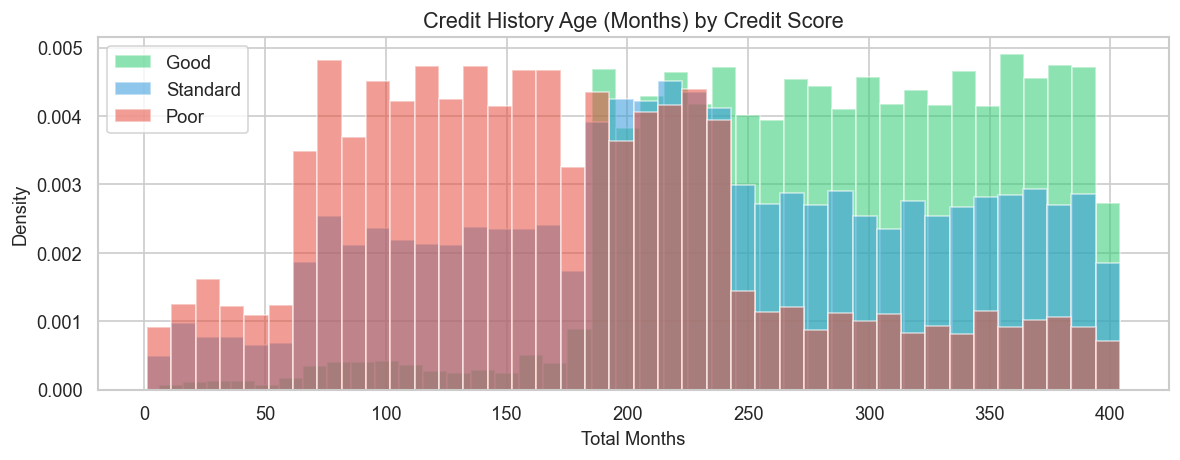

In [17]:
# Credit History Age: parse to total months
def parse_credit_history_age(val):
    if pd.isna(val):
        return np.nan
    import re
    match = re.search(r'(\d+)\s+Years?\s+and\s+(\d+)\s+Months?', str(val))
    if match:
        return int(match.group(1)) * 12 + int(match.group(2))
    return np.nan

train_eda['Credit_History_Months'] = train_eda['Credit_History_Age'].apply(parse_credit_history_age)

fig, ax = plt.subplots(figsize=(10, 4))
for score in order:
    subset = train_eda[train_eda['Credit_Score'] == score]['Credit_History_Months'].dropna()
    ax.hist(subset, bins=40, alpha=0.55, label=score, color=COLORS[score], density=True)
ax.set_title('Credit History Age (Months) by Credit Score')
ax.set_xlabel('Total Months')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Categorical Features Analysis <a id='7'></a>

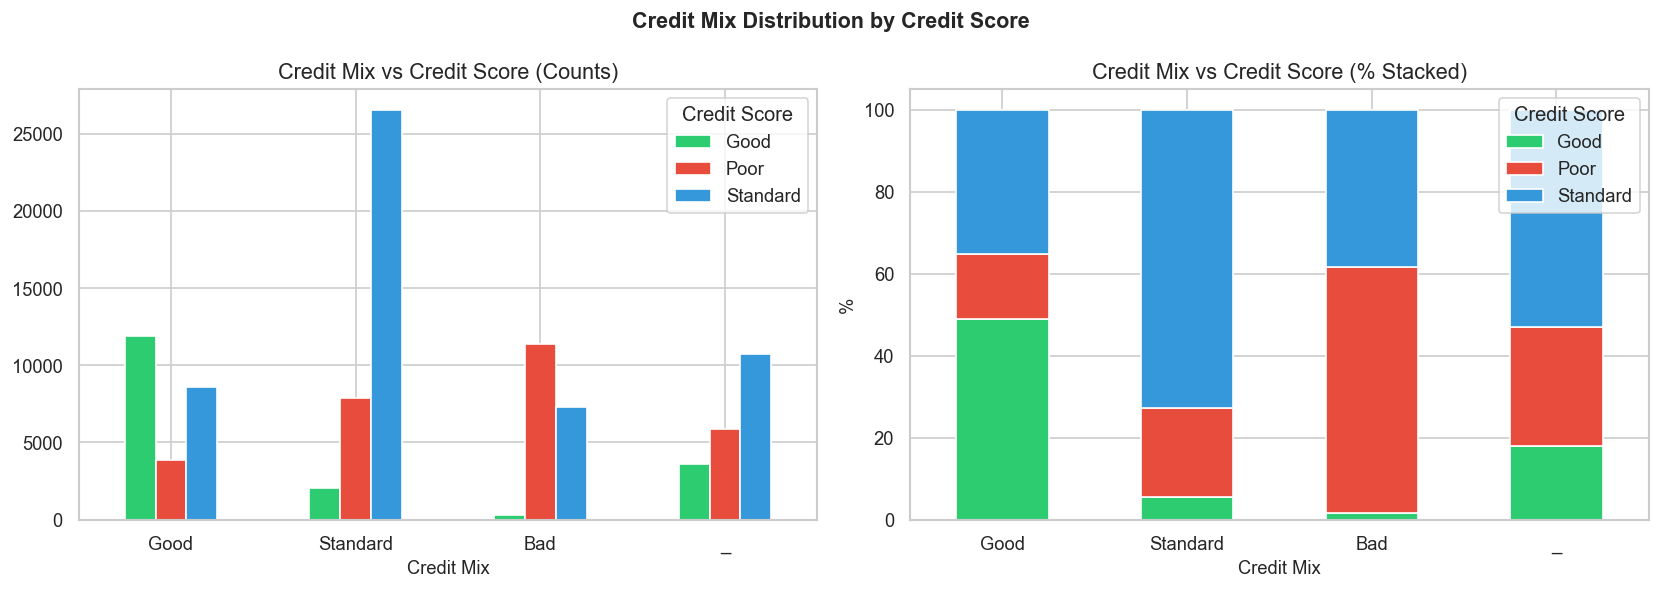

In [18]:
# Credit Mix vs Credit Score
cm_order = ['Good', 'Standard', 'Bad', '_']
cm_counts = train.groupby(['Credit_Mix', 'Credit_Score']).size().unstack(fill_value=0)
cm_pct = cm_counts.div(cm_counts.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_counts.loc[cm_order].plot(kind='bar', ax=axes[0], color=[COLORS[c] for c in ['Good', 'Poor', 'Standard']],
                              edgecolor='white', rot=0)
axes[0].set_title('Credit Mix vs Credit Score (Counts)')
axes[0].set_xlabel('Credit Mix')
axes[0].legend(title='Credit Score')

cm_pct.loc[cm_order].plot(kind='bar', stacked=True, ax=axes[1],
                           color=[COLORS[c] for c in ['Good', 'Poor', 'Standard']],
                           edgecolor='white', rot=0)
axes[1].set_title('Credit Mix vs Credit Score (% Stacked)')
axes[1].set_xlabel('Credit Mix')
axes[1].set_ylabel('%')
axes[1].legend(title='Credit Score')

plt.suptitle('Credit Mix Distribution by Credit Score', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

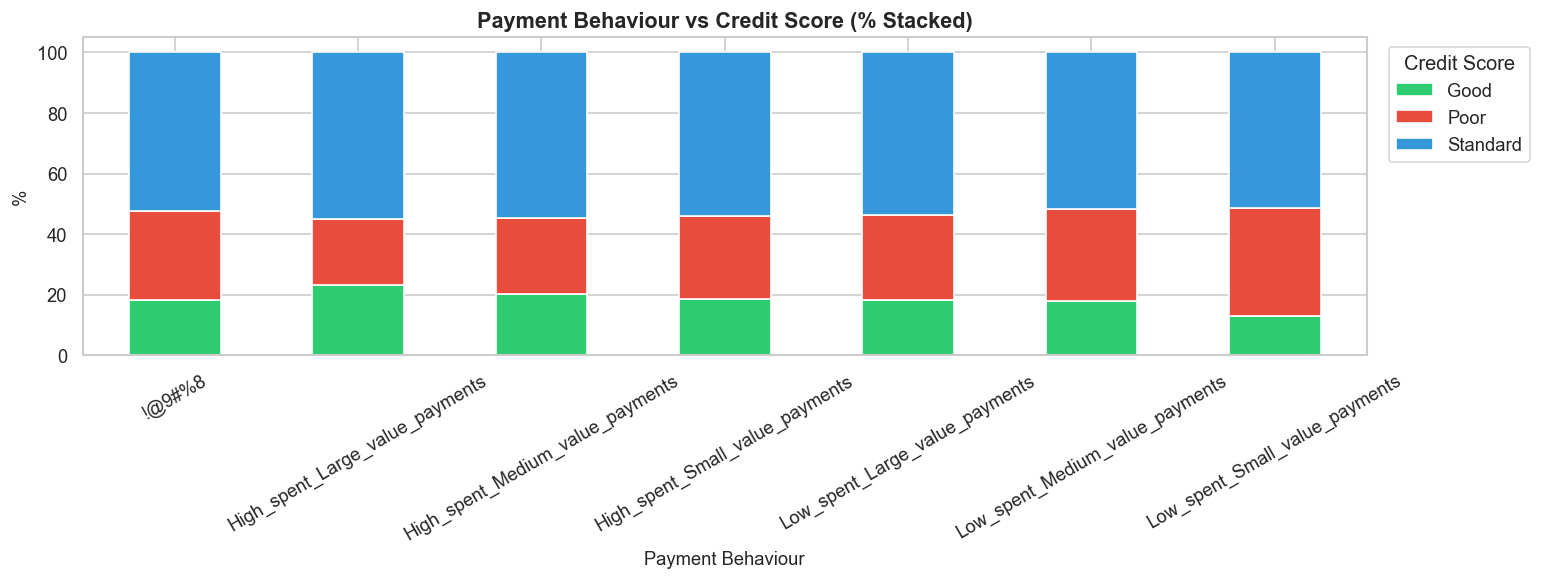

In [19]:
# Payment Behaviour vs Credit Score
pb_counts = train.groupby(['Payment_Behaviour', 'Credit_Score']).size().unstack(fill_value=0)
pb_pct = pb_counts.div(pb_counts.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 5))
pb_pct.plot(kind='bar', stacked=True, ax=ax,
            color=[COLORS[c] for c in ['Good', 'Poor', 'Standard']],
            edgecolor='white', rot=30)
ax.set_title('Payment Behaviour vs Credit Score (% Stacked)', fontweight='bold')
ax.set_xlabel('Payment Behaviour')
ax.set_ylabel('%')
ax.legend(title='Credit Score', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

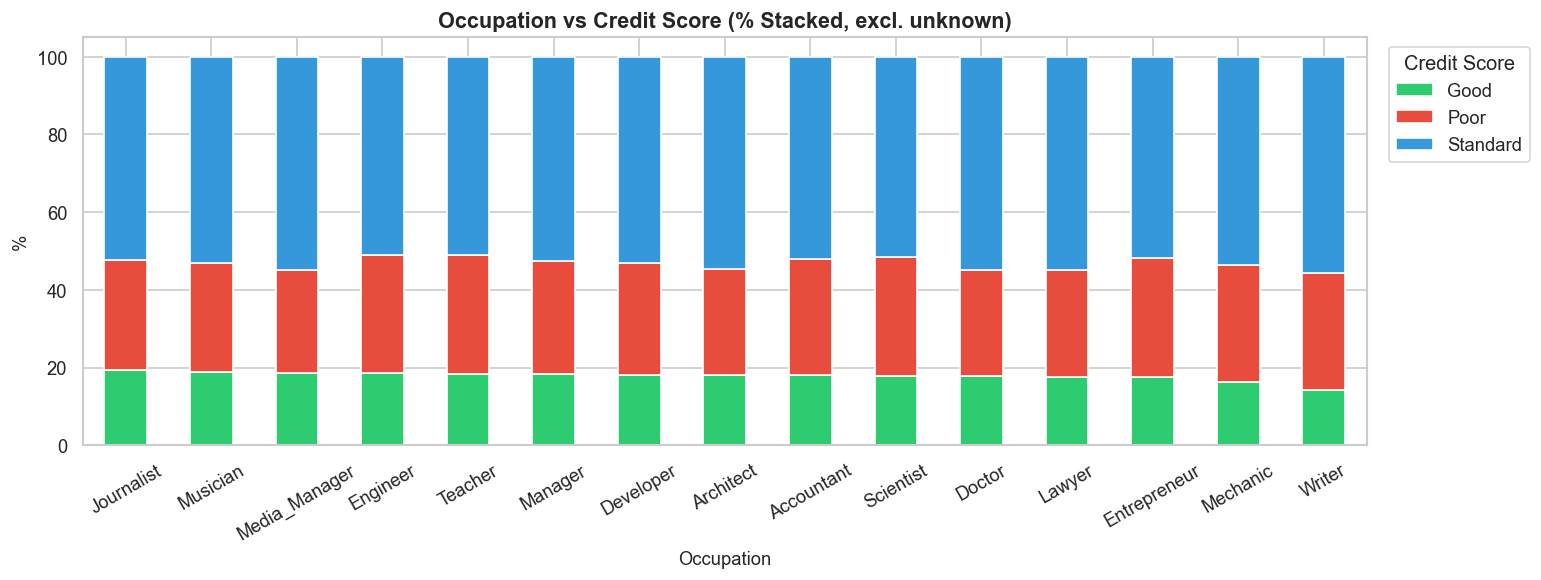

In [20]:
# Occupation vs Credit Score
occ_pct = train[train['Occupation'] != '_______'].groupby(['Occupation', 'Credit_Score']).size().unstack(fill_value=0)
occ_pct = occ_pct.div(occ_pct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 5))
occ_pct.sort_values('Good', ascending=False).plot(
    kind='bar', stacked=True, ax=ax,
    color=[COLORS[c] for c in ['Good', 'Poor', 'Standard']],
    edgecolor='white', rot=30
)
ax.set_title('Occupation vs Credit Score (% Stacked, excl. unknown)', fontweight='bold')
ax.set_xlabel('Occupation')
ax.set_ylabel('%')
ax.legend(title='Credit Score', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

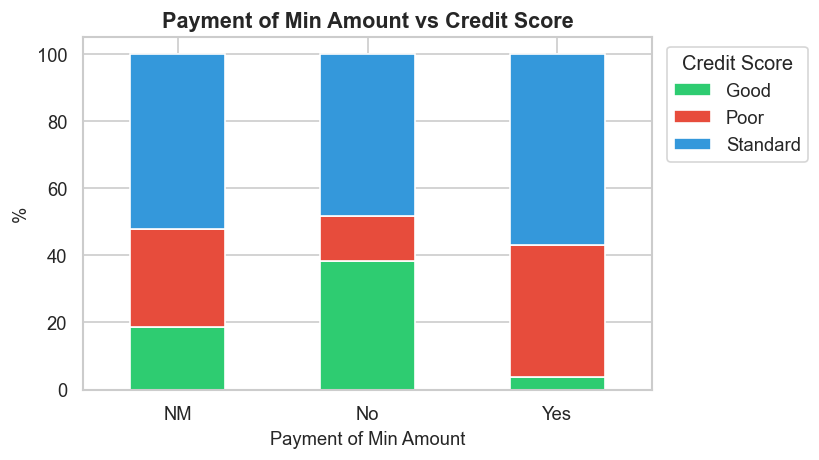

In [21]:
# Payment of Min Amount vs Credit Score
pma_counts = train.groupby(['Payment_of_Min_Amount', 'Credit_Score']).size().unstack(fill_value=0)
pma_pct = pma_counts.div(pma_counts.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(7, 4))
pma_pct.plot(kind='bar', stacked=True, ax=ax,
             color=[COLORS[c] for c in ['Good', 'Poor', 'Standard']],
             edgecolor='white', rot=0)
ax.set_title('Payment of Min Amount vs Credit Score', fontweight='bold')
ax.set_xlabel('Payment of Min Amount')
ax.set_ylabel('%')
ax.legend(title='Credit Score', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

## 8. Feature Correlations <a id='8'></a>

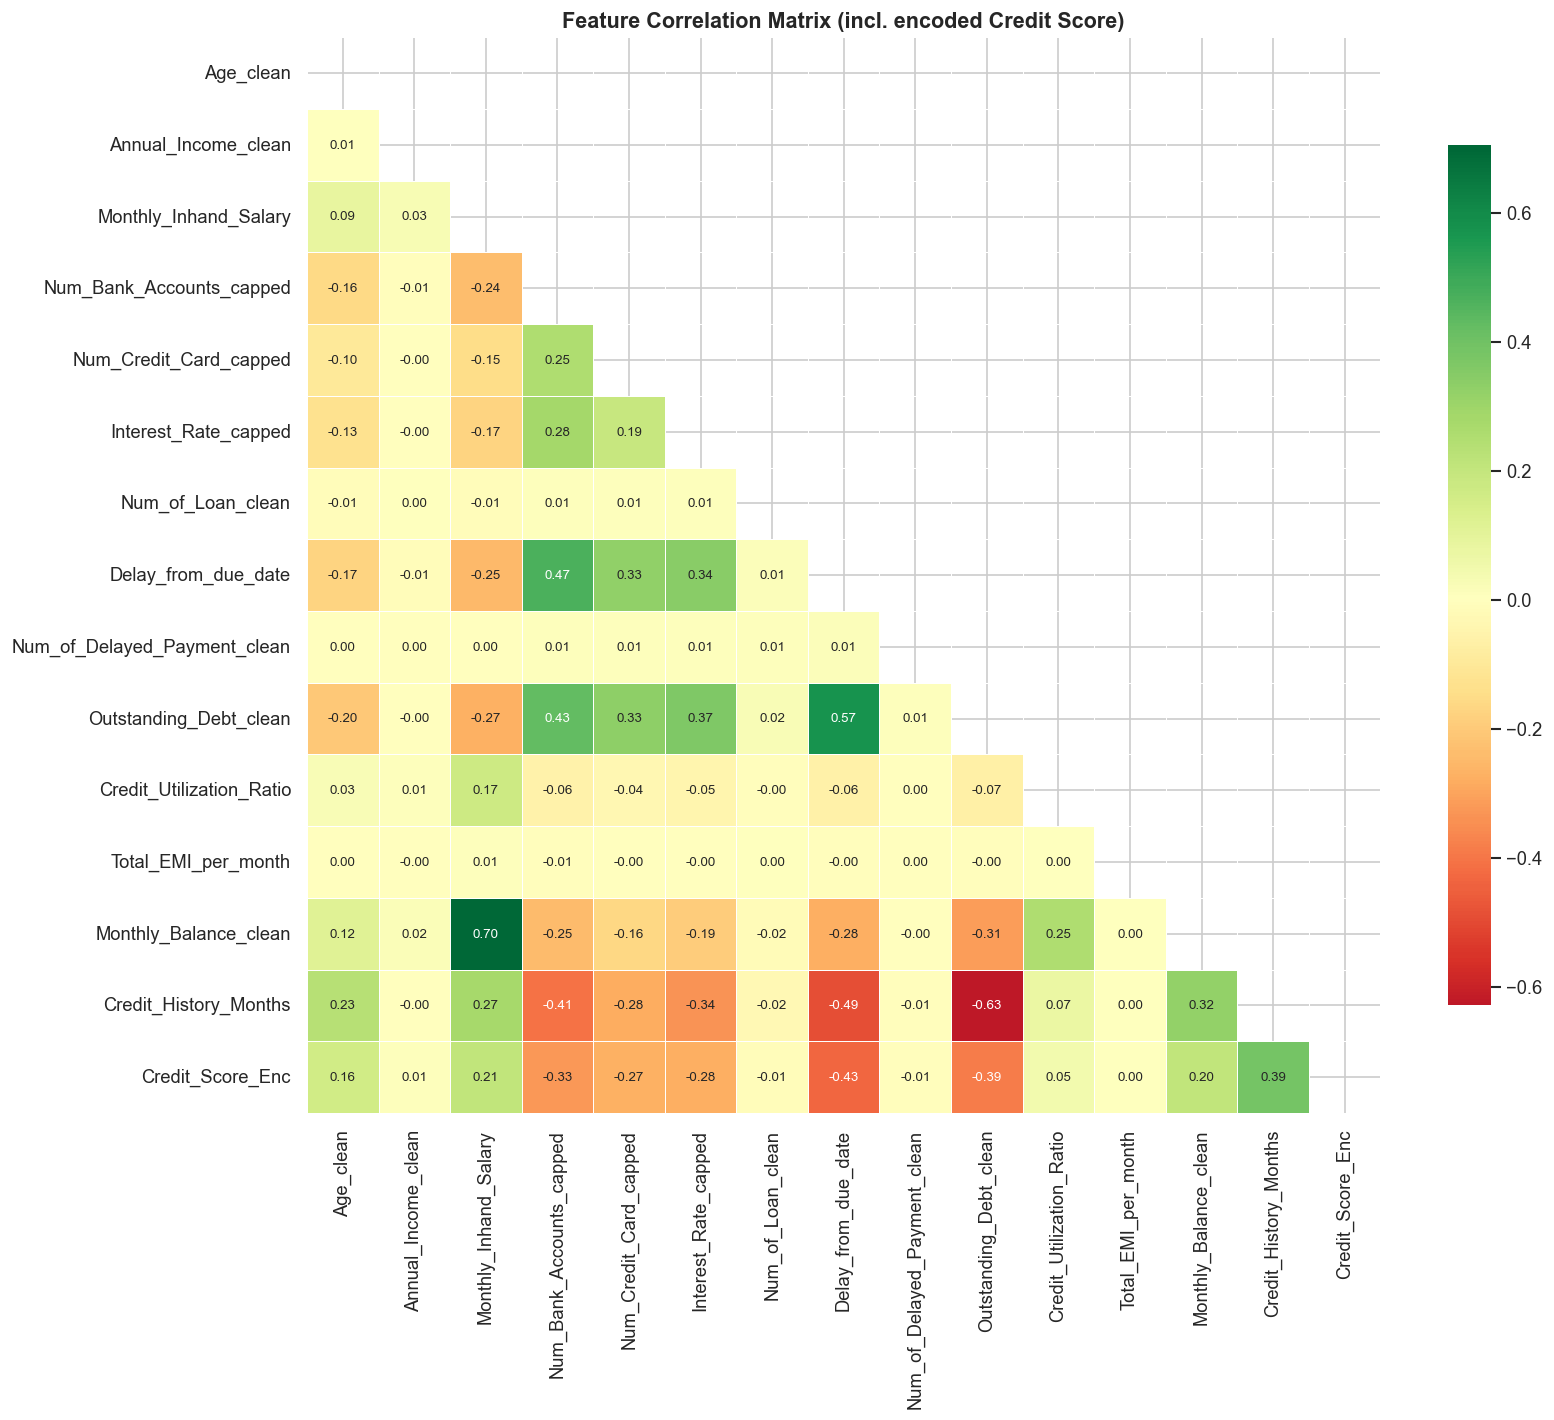

In [22]:
# Encode target for correlation analysis
label_map = {'Good': 2, 'Standard': 1, 'Poor': 0}
train_eda['Credit_Score_Enc'] = train_eda['Credit_Score'].map(label_map)

corr_cols = [
    'Age_clean', 'Annual_Income_clean', 'Monthly_Inhand_Salary',
    'Num_Bank_Accounts_capped', 'Num_Credit_Card_capped', 'Interest_Rate_capped',
    'Num_of_Loan_clean', 'Delay_from_due_date', 'Num_of_Delayed_Payment_clean',
    'Outstanding_Debt_clean', 'Credit_Utilization_Ratio', 'Total_EMI_per_month',
    'Monthly_Balance_clean', 'Credit_History_Months', 'Credit_Score_Enc'
]

corr_matrix = train_eda[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8},
    annot_kws={'size': 8}
)
ax.set_title('Feature Correlation Matrix (incl. encoded Credit Score)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

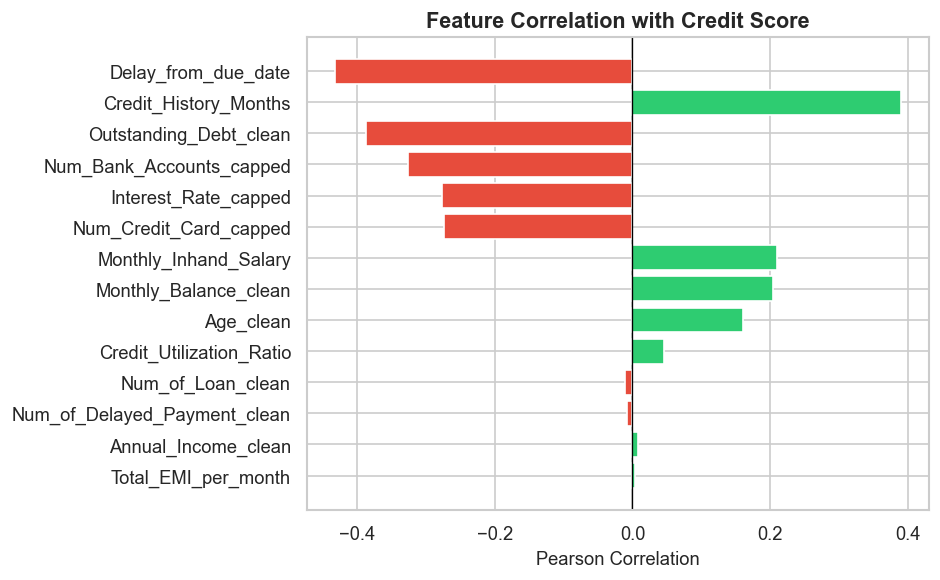

In [23]:
# Top correlations with Credit Score
target_corr = corr_matrix['Credit_Score_Enc'].drop('Credit_Score_Enc').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Credit Score', fontweight='bold')
ax.set_xlabel('Pearson Correlation')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Train / Validation Split <a id='9'></a>

**Strategy — Solution 2:**  
Split the labeled train set **80/20** into train and validation.  
The original test set is kept **untouched** for final inference/submission only.

| Split | Source | Size | Labels |
|---|---|---|---|
| Train | `_MLOps__train.csv` | 80,000 | ✅ Yes |
| Validation | `_MLOps__train.csv` | 20,000 | ✅ Yes |
| Test (inference) | `_MLOps__test.csv` | 50,000 | ❌ No (Kaggle submission) |

In [24]:
from sklearn.model_selection import train_test_split

# 80/20 stratified split on the labeled train set
train_set, valid_set = train_test_split(
    train,
    test_size=0.2,
    random_state=42,
    stratify=train['Credit_Score'],
    shuffle=True
)

train_set = train_set.reset_index(drop=True)
valid_set = valid_set.reset_index(drop=True)

print(f'Original labeled train : {train.shape}')
print(f'Train set              : {train_set.shape}')
print(f'Validation set         : {valid_set.shape}')
print(f'Test set (unlabeled)   : {test.shape}  <- untouched')

Original labeled train : (100000, 28)
Train set              : (80000, 28)
Validation set         : (20000, 28)
Test set (unlabeled)   : (50000, 27)  <- untouched


In [25]:
# Verify class proportions are preserved after stratified split
print('Credit Score proportions:\n')
print(f'{"Label":<12} {"Original":>10} {"Train":>10} {"Validation":>12}')
print('-' * 46)
for label in ['Good', 'Standard', 'Poor']:
    orig = (train['Credit_Score'] == label).mean() * 100
    tr   = (train_set['Credit_Score'] == label).mean() * 100
    val  = (valid_set['Credit_Score'] == label).mean() * 100
    print(f'{label:<12} {orig:>9.1f}%  {tr:>9.1f}%  {val:>11.1f}%')

Credit Score proportions:

Label          Original      Train   Validation
----------------------------------------------
Good              17.8%       17.8%         17.8%
Standard          53.2%       53.2%         53.2%
Poor              29.0%       29.0%         29.0%


In [26]:
# Verify Customer_ID overlap between train and validation
train_customers = set(train_set['Customer_ID'])
valid_customers = set(valid_set['Customer_ID'])
overlap = train_customers & valid_customers

print(f'Unique customers in train set  : {len(train_customers):,}')
print(f'Unique customers in valid set  : {len(valid_customers):,}')
print(f'Customer overlap               : {len(overlap):,}')
print()
if overlap:
    print('⚠️  Some customers appear in both splits.')
    print('   This is expected since each customer has 8 monthly records.')
    print('   For strict isolation, consider GroupShuffleSplit on Customer_ID.')
else:
    print('✅ No customer overlap between train and validation sets.')

Unique customers in train set  : 12,500
Unique customers in valid set  : 10,449
Customer overlap               : 10,449

⚠️  Some customers appear in both splits.
   This is expected since each customer has 8 monthly records.
   For strict isolation, consider GroupShuffleSplit on Customer_ID.


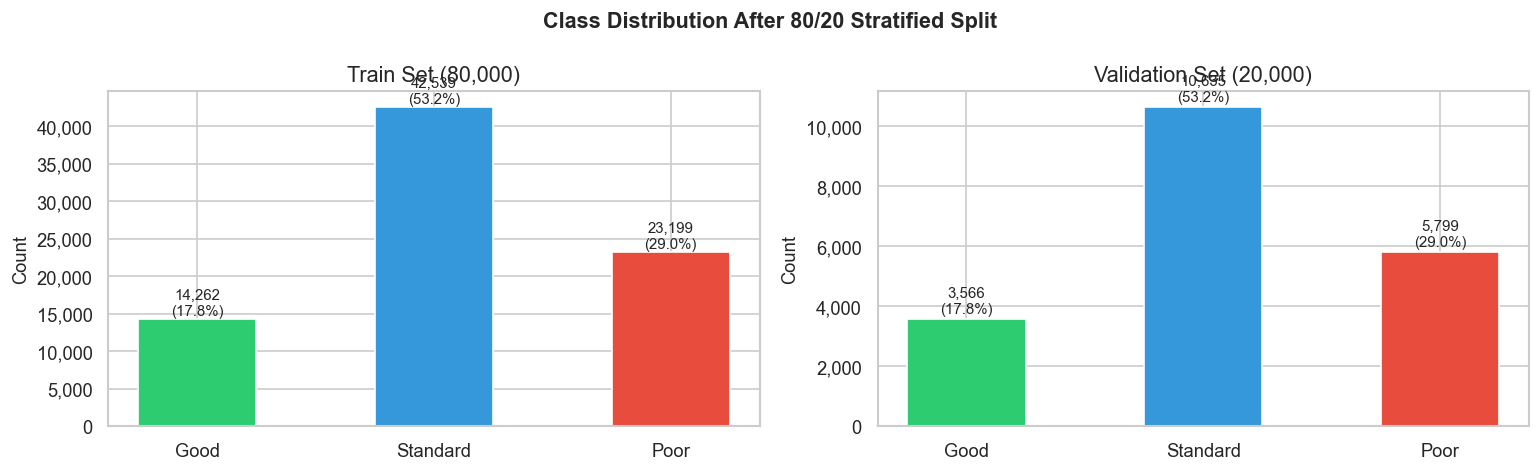

In [27]:
# Visual: class distribution across splits
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
order = ['Good', 'Standard', 'Poor']

for ax, df, title in zip(axes,
                          [train_set, valid_set],
                          ['Train Set (80,000)', 'Validation Set (20,000)']):
    counts = df['Credit_Score'].value_counts()
    bars = ax.bar(order, [counts[o] for o in order],
                  color=[COLORS[o] for o in order], edgecolor='white', width=0.5)
    for bar, label in zip(bars, order):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
                f'{counts[label]:,}\n({counts[label]/len(df)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9)
    ax.set_title(title)
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Class Distribution After 80/20 Stratified Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
# Save splits to CSV
train_set.to_csv(r"C:\Users\Admin\[MLOps] train_split.csv", index=False)
valid_set.to_csv(r"C:\Users\Admin\[MLOps] valid.csv", index=False)

print('✅ Saved: train_split.csv  (80,000 rows — labeled)')
print('✅ Saved: valid.csv  (20,000 rows — labeled)')
print('ℹ️  Test set (_MLOps__test.csv) kept untouched for final inference.')

✅ Saved: train_split.csv  (80,000 rows — labeled)
✅ Saved: valid.csv  (20,000 rows — labeled)
ℹ️  Test set (_MLOps__test.csv) kept untouched for final inference.


## 10. Key Findings Summary <a id='10'></a>

In [30]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║            EDA KEY FINDINGS — CREDIT SCORE DATASET              ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  TARGET VARIABLE                                                 ║
║  • 3 classes: Good (17.8%), Standard (53.2%), Poor (29.0%)       ║
║  • Class imbalance → apply class weighting during training       ║
║                                                                  ║
║  DATA QUALITY ISSUES (require cleaning before modelling)         ║
║  • Age: negative values & trailing chars (e.g. '28_', '-500')   ║
║  • SSN: corrupted values — drop column (PII, not useful)         ║
║  • Annual_Income / Outstanding_Debt: trailing underscores        ║
║  • Num_Credit_Card / Num_Bank_Accounts: extreme outliers         ║
║  • Monthly_Balance: garbage placeholder '__-333333...___'        ║
║  • Credit_Mix / Occupation / Changed_Credit_Limit: '_' placeholders║
║  • Payment_Behaviour: '!@9#%8' garbage category                 ║
║  • Payment_of_Min_Amount: 'NM' unknown category                  ║
║  • Credit_History_Age: string format → parse to total months     ║
║                                                                  ║
║  STRONGEST PREDICTORS OF CREDIT SCORE                            ║
║  • Delay_from_due_date          (negative correlation)           ║
║  • Num_of_Delayed_Payment       (negative correlation)           ║
║  • Outstanding_Debt             (negative correlation)           ║
║  • Credit_History_Months        (positive correlation)           ║
║  • Annual_Income / Monthly_Salary (positive correlation)         ║
║  • Credit_Mix (Good → higher credit score)                       ║
║                                                                  ║
║  COLUMNS TO DROP (PII / non-informative)                         ║
║  • ID, Customer_ID, Name, SSN, Month                             ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║            EDA KEY FINDINGS — CREDIT SCORE DATASET              ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  TARGET VARIABLE                                                 ║
║  • 3 classes: Good (17.8%), Standard (53.2%), Poor (29.0%)       ║
║  • Class imbalance → apply class weighting during training       ║
║                                                                  ║
║  DATA QUALITY ISSUES (require cleaning before modelling)         ║
║  • Age: negative values & trailing chars (e.g. '28_', '-500')   ║
║  • SSN: corrupted values — drop column (PII, not useful)         ║
║  • Annual_Income / Outstanding_Debt: trailing underscores        ║
║  • Num_Credit_Card / Num_Bank_Accounts: extreme outliers         ║
║  • Monthly_Balance: garbage placeholder '__-333333...___'        ║
║  • Credit_Mix / Occupation / Chan